In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [4]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [5]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [6]:
rate_col = "Renal Rate"

In [7]:
design_matrix_otrain[rate_col].mean()

0.4462676470588236

In [8]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

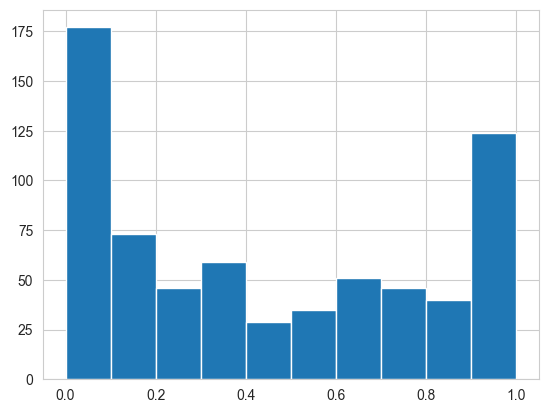

In [9]:
design_matrix_train[rate_col].hist(bins=10)

In [10]:
design_matrix_train['group'].value_counts()

group
1    364
2    316
Name: count, dtype: int64

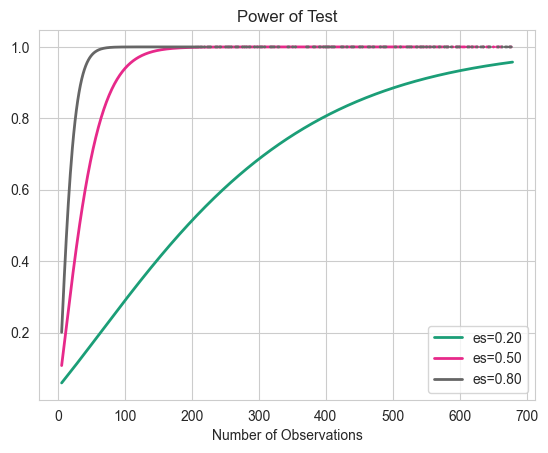

In [11]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [12]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [13]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [14]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [15]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

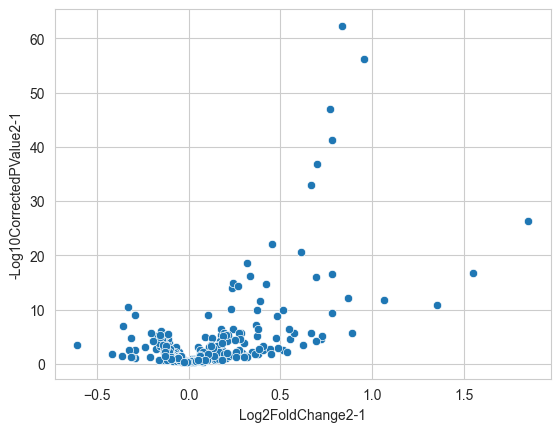

In [16]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [17]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
230,P01034,CYTC_HUMAN,1.097314,12.602245,11.766758,0.663443,0.473454,0.835487,4.157458e-65,316,...,12.388361,11.367966,11.808035,12.448976,11.842510,12.033297,11.763599,12.130882,11.829693,11.762052
123,P61769,B2MG_HUMAN,1.038176,12.477431,11.521218,0.854069,0.520907,0.956213,1.097297e-58,316,...,12.652368,10.490738,11.618301,12.289228,11.372313,11.781104,10.906047,11.750655,11.657643,12.220980
80,P00746,CFAD_HUMAN,0.862666,12.000215,11.232210,0.718447,0.522255,0.768006,2.086692e-49,316,...,11.758841,11.026146,11.914894,11.783697,10.489469,11.478523,11.510933,11.364108,11.175636,11.904981
146,P41222,PTGDS_HUMAN,0.787872,11.478268,10.695272,0.791765,0.573697,0.782995,1.668839e-43,316,...,10.507759,10.037824,10.779898,11.730896,10.193436,11.014198,10.388918,10.107603,10.411609,10.777951
217,P39060,COIA1_HUMAN,0.705411,10.143724,9.443321,0.655706,0.649312,0.700403,4.846027e-39,316,...,9.634904,8.969382,9.303124,10.259988,9.311042,10.097311,9.641211,9.908037,9.111742,9.492980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,P06396,GELS_HUMAN,0.002274,15.007366,15.011405,0.489953,0.445481,-0.004039,9.105434e-01,316,...,15.421840,15.405665,15.194701,15.742585,15.404076,15.152837,15.294037,14.626642,14.987387,14.778425
277,Q9NPH3,IL1AP_HUMAN,0.001158,10.396749,10.398823,0.502473,0.523411,-0.002074,9.581984e-01,316,...,10.359477,10.830893,11.205888,10.997268,9.489129,10.582078,10.919976,10.010054,9.905704,10.688069
278,Q8NHL6,LIRB1_HUMAN,0.004403,10.215793,10.223924,2.482403,2.382793,-0.008131,9.653474e-01,316,...,11.267581,10.801097,3.580505,11.202531,10.794325,11.028452,11.051211,13.015956,11.523656,13.387609
199,P11279,LAMP1_HUMAN,0.002841,8.713394,8.718629,1.490066,1.575565,-0.005235,9.647179e-01,316,...,9.226824,8.977360,9.533247,10.037906,9.273691,9.250855,9.578445,9.789875,8.568953,9.954256


In [18]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [19]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [20]:
protein_columns = training_data.columns.to_list()

In [21]:
len(protein_columns)

287

In [22]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.772177298592393,
 0.7999995555538625,
 0.8029511520018713,
 0.8009940370033725,
 0.9032307643054768)

In [25]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [26]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [27]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
CYTC_HUMAN,0.862555,0.633813,0.816605,0.770991
PTGDS_HUMAN,0.669579,0.920345,0.582132,0.724019
FA5_HUMAN,0.534686,0.897905,0.526265,0.652952
ZA2G_HUMAN,0.606115,0.611924,0.580696,0.599579
B2MG_HUMAN,0.584387,0.626733,0.545301,0.585473
...,...,...,...,...
APOM_HUMAN,0.047467,0.022211,0.013927,0.027868
CO2_HUMAN,0.000689,0.041414,0.038667,0.026923
PRDX2_HUMAN,0.001472,0.039447,0.038245,0.026388


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

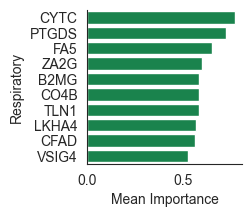

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "Renal"

In [34]:
feature_importance_results.to_csv(
    "renal_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/renal_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/renal_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
